### 🍉 Multi-class Fruits Classification 🍍

This notebook builds an multi-class image classifier with implementation of DBNs (Deep Belief Network).

1. Problem

Identifying whether a fruit is ripe or not based on its image.

2. Data

The data used is from : https://www.kaggle.com/datasets/mdsagorahmed/fruit-image-dataset-22-classes/data

3. Evaluation

The evaluation of the model we created .

4. Features :

Some info about the data :
   
   * We're dealing with images (unstructured data) so it's probably best we use deep learning / transfer-learning
   * There are :
        - Total number of images : over 8700
        - Number of classes : 22 (11 - ripe and 11 - unripe) fruits



# Getting our data ready (turning into Tensors)

With all machine learning models , our data has to be in numerical format . So that's what we'll be doing first . Turning our images into Tensors (numerical representation).

In [ ]:
# Unzip the uploaded data into Google Drive
#!unzip "drive/MyDrive/Colab Notebooks/FruitsVision/archive.zip" -d "drive/MyDrive/Colab Notebooks/FruitsVision"

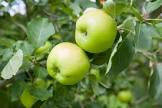

In [ ]:
# Let's view an image
from IPython.display import Image

Image("drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe apple/1.jpg")

### Getting images and their labels

Create a main folder from subfolders with images for train

In [ ]:
import os
import pandas as pd
'''
root_dir = "drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/"

data = []

for class_name in os.listdir(root_dir):
   class_path = os.path.join(root_dir , class_name)
   if os.path.isdir(class_path):
      for img_name in os.listdir(class_path):
         img_path = os.path.join(class_name , img_name)
         data.append([img_path , class_name])

df = pd.DataFrame(data , columns=["filename" , "label"])
df.to_csv("drive/MyDrive/Colab Notebooks/FruitsVision/data_fruits.csv" , index=False)
'''

'\nroot_dir = "drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/"\n\ndata = []\n\nfor class_name in os.listdir(root_dir):\n   class_path = os.path.join(root_dir , class_name)\n   if os.path.isdir(class_path):\n      for img_name in os.listdir(class_path):\n         img_path = os.path.join(class_name , img_name)\n         data.append([img_path , class_name])\n\ndf = pd.DataFrame(data , columns=["filename" , "label"])\ndf.to_csv("drive/MyDrive/Colab Notebooks/FruitsVision/data_fruits.csv" , index=False)\n'

In [ ]:
fruits_csv = pd.read_csv("drive/MyDrive/Colab Notebooks/FruitsVision/data_fruits.csv")
fruits_csv.head()

,filename,label
0,ripe apple/1.jpg,ripe apple
1,ripe apple/10.jpg,ripe apple
2,ripe apple/100.jpg,ripe apple
3,ripe apple/101.jpg,ripe apple
4,ripe apple/102.jpg,ripe apple


<Axes: xlabel='label'>

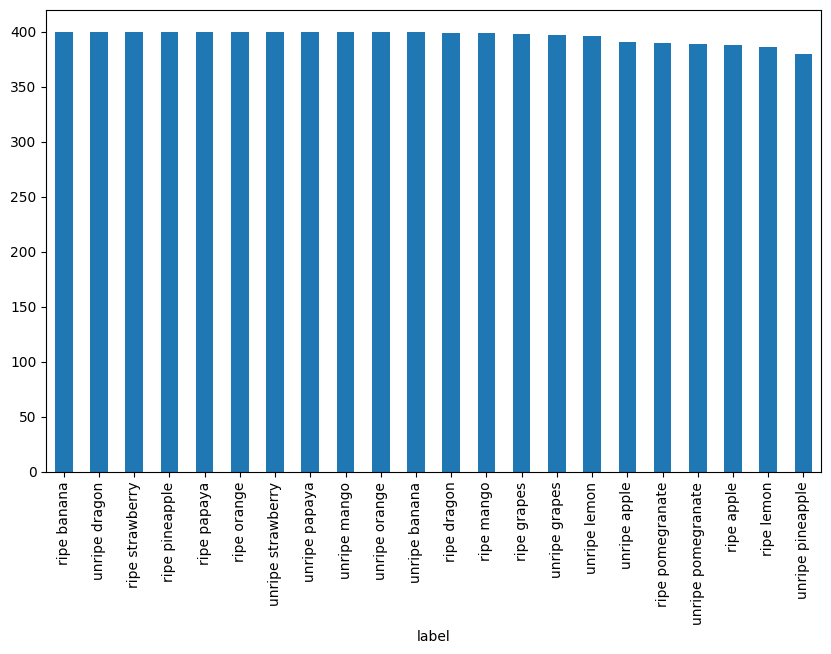

In [ ]:
# Images for each type of fruit
fruits_csv["label"].value_counts().plot.bar(figsize=(10,6))

In [ ]:
fruits_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8713 entries, 0 to 8712
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  8713 non-null   object
 1   label     8713 non-null   object
dtypes: object(2)
memory usage: 136.3+ KB


In [ ]:
# Set number of images to use for experimenting
NUM_IMAGES = 8713 #@param {type:"slider" , min:1000 , max:10000 , step:1000}

In [ ]:
df_shuffled = fruits_csv.sample(frac=1 , random_state=42).reset_index(drop=True)
df_subset = df_shuffled[:NUM_IMAGES]
df_subset.head()

,filename,label
0,unripe lemon/274.jpg,unripe lemon
1,ripe grapes/297.jpg,ripe grapes
2,ripe lemon/66.jpg,ripe lemon
3,unripe orange/207.jpg,unripe orange
4,ripe mango/4.jpg,ripe mango


In [ ]:
# Create pathnames from Image ID's
filename = ["drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/" + filename for filename in df_subset["filename"]]

# Check first 10
filename[:10]

['drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe lemon/274.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/ripe grapes/297.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/ripe lemon/66.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe orange/207.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/ripe mango/4.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/ripe lemon/224.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/ripe banana/158.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe lemon/177.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe orange/55.jpg',
 'drive/MyDrive/Colab Notebooks/FruitsVision/Ripe & Unripe Fruits/unripe apple/109.jpg']

ripe papaya


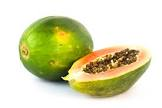

In [ ]:
print(df_subset["label"][20])
Image(filename[20])

In [ ]:
import numpy as np

labels = df_subset["label"].to_numpy()
labels

array(['unripe lemon', 'ripe grapes', 'ripe lemon', ..., 'unripe dragon',
       'ripe dragon', 'unripe papaya'], dtype=object)

In [ ]:
len(filename) == len(labels)

True

In [ ]:
# Find unique label values
unique_label = np.unique(labels)
len(unique_label)

22

In [ ]:
# Turn lables into a boolean array
boolean_labels = [label == unique_label for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False,
        False, False, False, False]),
 array([False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False])]

Change data into numbers

In [ ]:
import numpy as np
from PIL import Image

IMG_SIZE = 32

def process_image(image_path , image_size = IMG_SIZE) :
    img = Image.open(image_path).convert('RGB')
    img = img.resize((image_size , image_size))
    img_array = np.array(img).astype(np.float32) / 255.0
    img_vector = img_array.flatten()
    return img_vector

In [ ]:
def reconstruct_image(img_vector, image_size=IMG_SIZE):
    img_array = img_vector.reshape((image_size, image_size, 3))
    img_array = (img_array * 255).astype(np.uint8)
    img = Image.fromarray(img_array)
    return img


In [ ]:
X_array = np.array([process_image(path) for path in filename[:NUM_IMAGES]])
#y_array = np.array(boolean_labels[:NUM_IMAGES]).astype(int)

In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_array = le.fit_transform(labels[:NUM_IMAGES])

## Creating validation set

In [ ]:
# Setup X & y variables
X = X_array
y = y_array

Experimenting with 2000 images

In [ ]:
# Split data into train and validation
from sklearn.model_selection import train_test_split

X_train , X_val , y_train , y_val = train_test_split(X , y , stratify=y , test_size=0.2 , random_state=42)

len(X_train) , len(y_train) , len(X_val) , len(y_val)

(6970, 6970, 1743, 1743)

Train Model

In [ ]:
# DBN algorithm

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import BernoulliRBM
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV


# Initialize RBM model
rbm1 = BernoulliRBM(n_components=564 , learning_rate=0.01 , n_iter=500 , verbose=1 , random_state=42)
rbm1.fit(X_train)
X_train_rbm1 = rbm1.transform(X_train)
X_test_rbm1 = rbm1.transform(X_val)


rbm2 = BernoulliRBM(n_components=254 , learning_rate=0.02 , n_iter=200 , verbose=1, random_state=42)
rbm2.fit(X_train_rbm1)
X_train_rbm2 = rbm2.transform(X_train_rbm1)
X_test_rbm2 = rbm2.transform(X_test_rbm1)

# MLP : classifier (fine-tunning)
mlp = MLPClassifier(hidden_layer_sizes=(128,64) , activation='relu' , max_iter=200 , solver="adam" , verbose=True , random_state=42)

# Train DBN
mlp.fit(X_train_rbm2 , y_train)

# Train score
accuracy = mlp.score(X_train_rbm2 , y_train)
print(f"Accuracy for trained DBN on training data : {accuracy*100:.2f}%")

[BernoulliRBM] Iteration 1, pseudo-likelihood = -1903.49, time = 39.85s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -1866.52, time = 27.83s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -1846.49, time = 24.35s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -1858.88, time = 27.42s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -1825.66, time = 27.81s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -1852.64, time = 32.36s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -1788.00, time = 27.98s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -1742.61, time = 28.09s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -1752.85, time = 28.44s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -1764.79, time = 28.33s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -1736.04, time = 25.72s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -1711.61, time = 25.82s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -1750.32, time = 28.14s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -1711.72, t

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy for trained DBN on training data : 54.36%


In [ ]:
  # Predictions with the trained model
y_pred = mlp.predict(X_test_rbm2)

val_accuracy = mlp.score(X_test_rbm2 , y_val)
print(f"Accuracy on validation data : {val_accuracy*100:.2f}%")

print("Classification Report :")
print(classification_report(y_val , y_pred))

Accuracy on validation data : 23.75%
Classification Report :
              precision    recall  f1-score   support

           0       0.14      0.06      0.09        78
           1       0.30      0.53      0.38        80
           2       0.35      0.25      0.29        80
           3       0.24      0.14      0.17        80
           4       0.19      0.21      0.20        77
           5       0.30      0.26      0.28        80
           6       0.24      0.35      0.28        80
           7       0.37      0.36      0.37        80
           8       0.28      0.31      0.29        80
           9       0.43      0.47      0.45        78
          10       0.20      0.16      0.18        80
          11       0.16      0.18      0.17        78
          12       0.31      0.21      0.25        80
          13       0.21      0.26      0.23        80
          14       0.27      0.22      0.24        79
          15       0.20      0.11      0.15        79
          16       0

True value : unripe apple | Predicted value : unripe apple


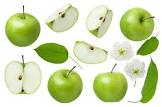

In [ ]:
# Let see an prediction
index = 3

true_label = labels[y_val[index]]
predicted_label = labels[y_pred[index]]

print(f"True value : {true_label} | Predicted value : {predicted_label}")
Image(filename[y_val[index]])